## 1. Setup and changing

+-------------------+-----------+-----------+--------+--------+--------+----------+----------+-------------+----------+----------+---------+--------------+--------+------+------------+------------+-------------------+------------+----+---+-----+-------+-------+--------------------+------------+------------+----+-------+-----------+---------------+---------------+----------+----------+--------------+--------------+
|               time|       city|temperature|temp_min|temp_max|humidity|feels_like|visibility|precipitation|cloudcover|wind_speed|wind_gust|wind_direction|pressure|is_day|weather_code|weather_main|weather_description|weather_icon|hour|day|month|weekday| region|          temp_range|wind_dir_sin|wind_dir_cos|rain|extreme| temp_level| humidity_level| pressure_level|wind_level|temp_lag_1|humidity_lag_1|pressure_lag_1|
+-------------------+-----------+-----------+--------+--------+--------+----------+----------+-------------+----------+----------+---------+--------------+--------+

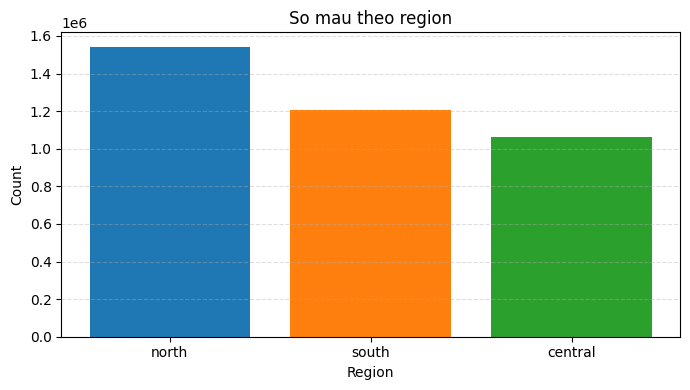

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, array, concat, lit, size, array_contains, expr
)

aws_access_key = os.getenv("AWS_ACCESS_KEY_ID", "minioadmin")
aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin123")
aws_region = os.getenv("AWS_REGION", "us-east-1")
minio_endpoint = os.getenv("S3_ENDPOINT", "http://minio:9000")
bronze_input_path = os.getenv("BRONZE_WEATHER_PATH", "s3a://iceberg/bronze/weather_raw_parquet/")
spark_master = os.getenv("SPARK_MASTER_URL")
spark_packages = os.getenv("SPARK_JARS_PACKAGES", "").strip()

spark_builder = SparkSession.builder.appName("Weather-KMeans-Apriori")
if spark_master:
    spark_builder = spark_builder.master(spark_master)

if spark_packages:
    spark_builder = spark_builder \
        .config("spark.jars.packages", spark_packages) \
        .config("spark.jars.repositories", "https://repo1.maven.org/maven2")

spark = spark_builder \
    .config("spark.hadoop.fs.s3a.endpoint", minio_endpoint) \
    .config("spark.hadoop.fs.s3a.access.key", aws_access_key) \
    .config("spark.hadoop.fs.s3a.secret.key", aws_secret_key) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

df = spark.read.parquet(bronze_input_path)

assert "region" in df.columns, "Colonne 'region' manquante — relancer preprocessing.py"

df.show(5)
df.printSchema()
print("Regions:", [r["region"] for r in df.select("region").distinct().collect()])

# Chart 1: so mau theo region
pdf_region = df.groupBy("region").count().toPandas().sort_values("count", ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(pdf_region["region"], pdf_region["count"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("So mau theo region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Feature Engineering

+-------+--------+-------+
| region| extreme|  count|
+-------+--------+-------+
|central|heatwave|  26740|
|central|  normal|1035363|
|  north|heatwave|  28171|
|  north|  normal|1514026|
|  south|heatwave|   4237|
|  south|  normal|1202376|
+-------+--------+-------+



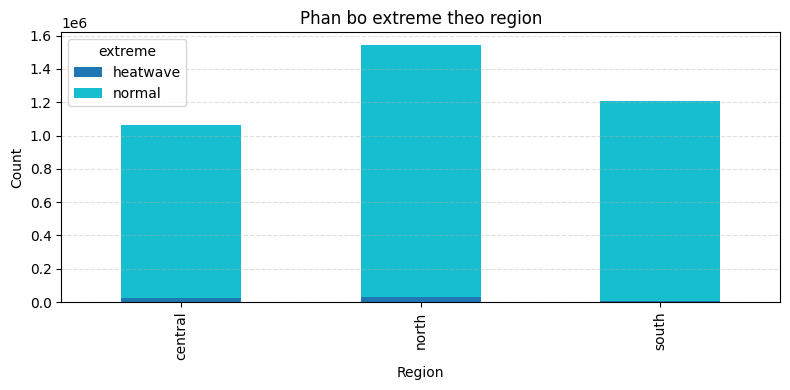

In [2]:
# temp_range và extreme đã có sẵn từ preprocessing.py
# Chỉ kiểm tra phân bố
df.groupBy("region", "extreme").count().orderBy("region", "extreme").show(30)

# Chart 2: extreme theo region
pdf_extreme = df.groupBy("region", "extreme").count().toPandas()
pivot_extreme = pdf_extreme.pivot_table(index="region", columns="extreme", values="count", aggfunc="sum").fillna(0)
pivot_extreme.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab10")
plt.title("Phan bo extreme theo region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Discretization

+-------+-----------+---------------+----------+-------+----------+
| region| temp_level| humidity_level|wind_level|extreme|rain_label|
+-------+-----------+---------------+----------+-------+----------+
|central|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  south|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  south|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|  rain_yes|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|  rain_yes|
+-------+-----------+---------------+----------+-------+----------+
only showing top 10 rows


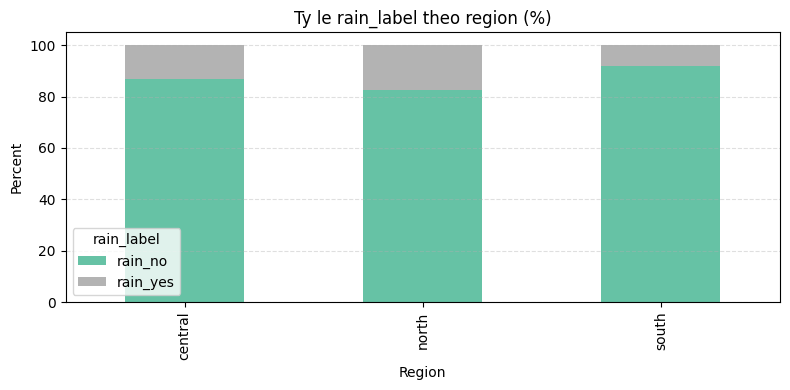

In [3]:
# temp_level, humidity_level, pressure_level, wind_level đã có từ preprocessing.py
# Chỉ tạo thêm rain_label (string) cho FPGrowth — preprocessing chỉ có cột rain (0/1)
df = df.withColumn("rain_label",
    when(col("precipitation") > 0, "rain_yes").otherwise("rain_no")
)

df.select("region", "temp_level", "humidity_level", "wind_level",
          "extreme", "rain_label").show(10)

# Chart 3: ti le rain_yes / rain_no theo region
pdf_rain = df.groupBy("region", "rain_label").count().toPandas()
pivot_rain = pdf_rain.pivot_table(index="region", columns="rain_label", values="count", aggfunc="sum").fillna(0)
(pivot_rain.div(pivot_rain.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, figsize=(8, 4), colormap="Set2"
)
plt.title("Ty le rain_label theo region (%)")
plt.xlabel("Region")
plt.ylabel("Percent")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Sample size: 762,227 rows

   k          WCSS    Silhouette
--------------------------------
   2     2236201.1        0.5518
   3     1837660.4        0.3866
   4     1568908.6        0.3933
   5     1390505.4        0.3851
   6     1217774.8        0.4115
   7     1121181.0        0.3615
   8     1023826.2        0.3585


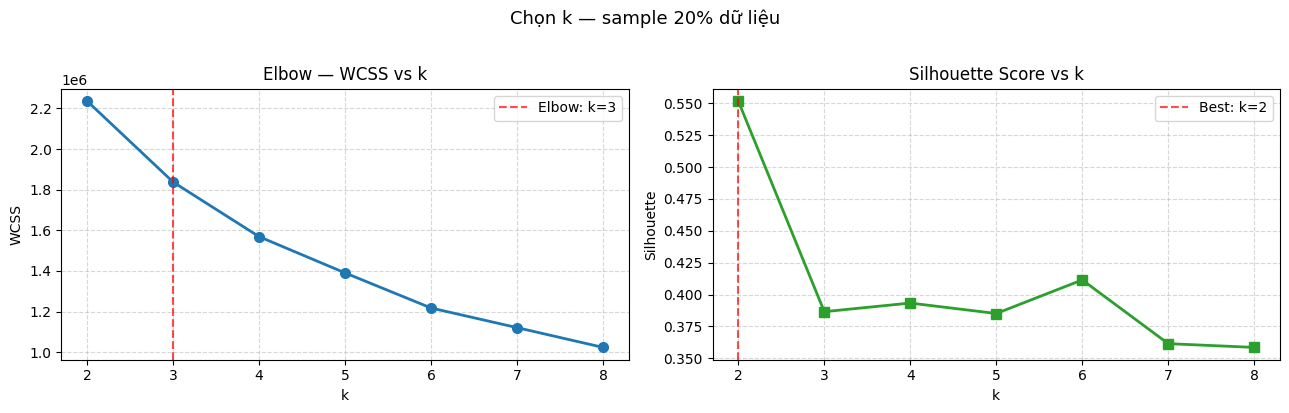


Elbow gợi ý: k=3  |  Silhouette tốt nhất: k=2
→ Dùng k mà cả hai đồng ý, hoặc ưu tiên Silhouette nếu khác nhau.


In [4]:
## TÌM K TỐI ƯU — phiên bản nhanh (sample + Elbow + Silhouette)
## Chèn TRƯỚC cell KMeans hiện tại

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# 1. Sample để tăng tốc — chỉnh SAMPLE_FRAC nếu muốn
# ----------------------------------------------------------
SAMPLE_FRAC = 0.2   # dùng 20% data; tăng lên 0.3 nếu muốn chính xác hơn
SEED        = 42

features = ["temp_max", "temp_min", "humidity", "pressure", "wind_speed"]
# Bỏ temp_range vì = temp_max - temp_min (phụ thuộc tuyến tính)

df_sample = df.sample(fraction=SAMPLE_FRAC, seed=SEED)

assembler = VectorAssembler(inputCols=features, outputCol="features_raw", handleInvalid="skip")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

df_vec    = assembler.transform(df_sample)
df_scaled = scaler.fit(df_vec).transform(df_vec).select("features").persist()
print(f"Sample size: {df_scaled.count():,} rows")

# ----------------------------------------------------------
# 2. Elbow + Silhouette — k từ 2 đến 8
# ----------------------------------------------------------
K_RANGE   = range(2, 9)
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")

wcss_list, sil_list = [], []
print("\n{:>4}  {:>12}  {:>12}".format("k", "WCSS", "Silhouette"))
print("-" * 32)

for k in K_RANGE:
    model  = KMeans(k=k, seed=SEED, maxIter=20, featuresCol="features").fit(df_scaled)
    pred   = model.transform(df_scaled)
    wcss   = model.summary.trainingCost
    sil    = evaluator.evaluate(pred)
    wcss_list.append(wcss)
    sil_list.append(sil)
    print(f"{k:>4}  {wcss:>12.1f}  {sil:>12.4f}")

df_scaled.unpersist()

# ----------------------------------------------------------
# 3. Vẽ biểu đồ
# ----------------------------------------------------------
ks = list(K_RANGE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ks, wcss_list, "o-", color="#1f77b4", lw=2, ms=7)
ax1.set_title("Elbow — WCSS vs k"); ax1.set_xlabel("k"); ax1.set_ylabel("WCSS")
ax1.set_xticks(ks); ax1.grid(True, ls="--", alpha=0.5)

# Tự phát hiện elbow bằng đạo hàm bậc 2
d2        = np.diff(np.diff(np.array(wcss_list)))
elbow_k   = ks[int(np.argmax(np.abs(d2))) + 1]
ax1.axvline(x=elbow_k, color="red", ls="--", alpha=0.7, label=f"Elbow: k={elbow_k}")
ax1.legend()

ax2.plot(ks, sil_list, "s-", color="#2ca02c", lw=2, ms=7)
ax2.set_title("Silhouette Score vs k"); ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")
ax2.set_xticks(ks); ax2.grid(True, ls="--", alpha=0.5)

best_k = ks[int(np.argmax(sil_list))]
ax2.axvline(x=best_k, color="red", ls="--", alpha=0.7, label=f"Best: k={best_k}")
ax2.legend()

plt.suptitle(f"Chọn k — sample {int(SAMPLE_FRAC*100)}% dữ liệu", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nElbow gợi ý: k={elbow_k}  |  Silhouette tốt nhất: k={best_k}")
print("→ Dùng k mà cả hai đồng ý, hoặc ưu tiên Silhouette nếu khác nhau.")

## 4. K-Means clustering

+-------+-------+------+
| region|cluster| count|
+-------+-------+------+
|central|      0|534193|
|central|      1|360181|
|central|      2|167729|
|  north|      0|849411|
|  north|      1|413296|
|  north|      2|279490|
|  south|      0|546127|
|  south|      1|313022|
|  south|      2|347464|
+-------+-------+------+



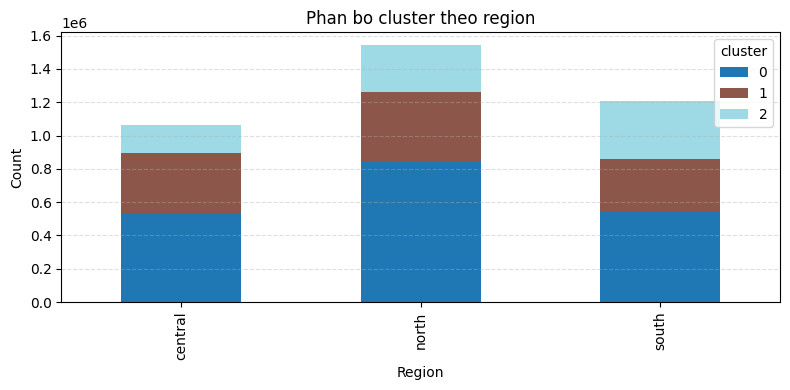

In [5]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

features = ["temp_range", "humidity", "pressure", "wind_speed"]

assembler = VectorAssembler(inputCols=features, outputCol="features_raw", handleInvalid="skip")
df = assembler.transform(df)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True)
df = scaler.fit(df).transform(df)

kmeans_model = KMeans(k=3, seed=42, maxIter=20).fit(df)
df = kmeans_model.transform(df).withColumnRenamed("prediction", "cluster")

df.groupBy("region", "cluster").count().orderBy("region", "cluster").show(30)

# Chart 4: phan bo cluster theo region
pdf_cluster_count = df.groupBy("region", "cluster").count().toPandas()
pivot_cluster = pdf_cluster_count.pivot_table(index="region", columns="cluster", values="count", aggfunc="sum").fillna(0)
pivot_cluster.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab20")
plt.title("Phan bo cluster theo region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Visualisation clusters by region

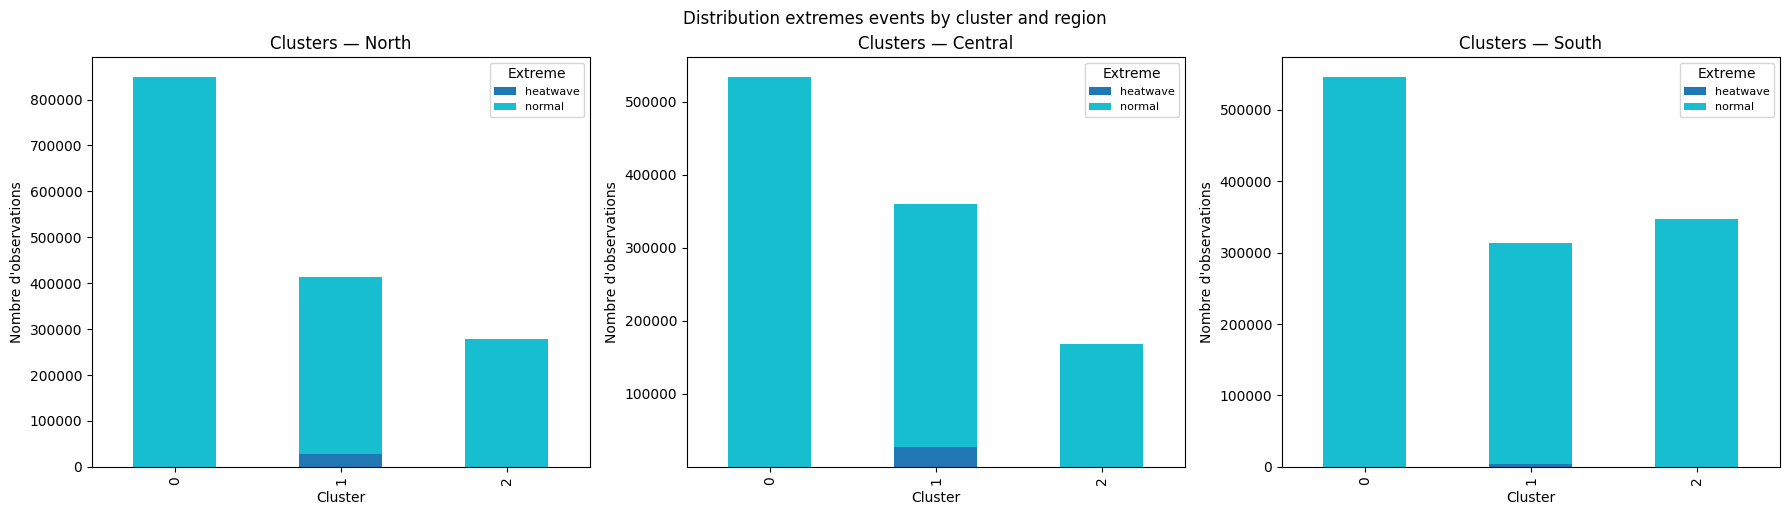

In [6]:
pdf_cluster = df.groupBy("region", "cluster", "extreme").count().toPandas()  # df global OK ici

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, region in zip(axes, ["north", "central", "south"]):
    sub = pdf_cluster[pdf_cluster["region"] == region]
    pivot = sub.pivot_table(
        index="cluster", columns="extreme", values="count", aggfunc="sum"
    ).fillna(0)
    pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set_title(f"Clusters — {region.capitalize()}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Nombre d'observations")
    ax.legend(title="Extreme", fontsize=8)

plt.tight_layout()
plt.suptitle("Distribution extremes events by cluster and region", y=1.02)
plt.show()


## 6. Apriori (FPGrowth) — association rules by region

**2 items separates :**
- `items_ctx` : variables climate + cluster (antécédents)
- `items_full` : items_ctx + target (`rain_yes` / label extrême)

Executing FPGrowth on `items_full`, then filter rules **consequence is the target**.


In [7]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import array_contains

# Items contexte : variables prédictives (PAS de region_ car on filtre déjà par région)
df = df.withColumn(
    "items_full",
    array(
        col("temp_level"),
        col("humidity_level"),
        col("wind_level"),
        col("pressure_level"),
        concat(lit("cluster_"), col("cluster").cast("string")),
        col("rain_label"),    # target pluie
        col("extreme")        # target extrême
    )
)
df = df.withColumn("items_ctx", array(
    col("temp_level"), col("humidity_level"),
    col("wind_level"), col("pressure_level"),
    concat(lit("cluster_"), col("cluster").cast("string"))
))

### Split dataset by region

> execute **after** the creation of `items_full`, so that `df_north`, `df_central`, `df_south` inherit all the columns.

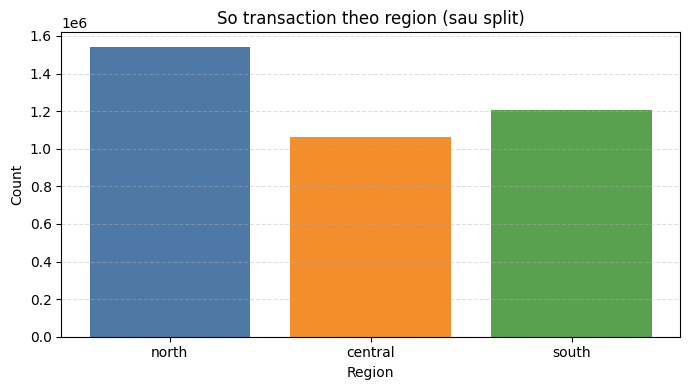

In [8]:
# Split APRÈS que toutes les colonnes (items_full, cluster, etc.) sont créées
df_north   = df.filter(col('region') == 'north')
df_central = df.filter(col('region') == 'central')
df_south   = df.filter(col('region') == 'south')

dfs_by_region = {
    'north'  : df_north,
    'central': df_central,
    'south'  : df_south,
}

# Chart 5: so transaction theo region sau split
region_sizes = {
    "north": df_north.count(),
    "central": df_central.count(),
    "south": df_south.count(),
}
plt.figure(figsize=(7, 4))
plt.bar(region_sizes.keys(), region_sizes.values(), color=["#4e79a7", "#f28e2b", "#59a14f"])
plt.title("So transaction theo region (sau split)")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


  Region : NORTH
  min_support=0.005  min_confidence=0.1
  Transactions: 1,542,197 | Partitions: 32
  >> Tổng frequent itemsets: 1483
  >> Top 10 itemsets:
+---------------------------+-------+
|items                      |freq   |
+---------------------------+-------+
|[wind_low]                 |1537216|
|[normal]                   |1514026|
|[normal, wind_low]         |1509053|
|[rain_no]                  |1270301|
|[rain_no, wind_low]        |1268106|
|[rain_no, normal]          |1244752|
|[rain_no, normal, wind_low]|1242565|
|[pressure_normal]          |1237151|
|[pressure_normal, wind_low]|1233489|
|[pressure_normal, normal]  |1230179|
+---------------------------+-------+

  >> 200 rules về rain/extreme
+---------------------------------------------------------------------+----------+--------------------+------------------+------------------+
|antecedent                                                           |consequent|support             |confidence        |lift           

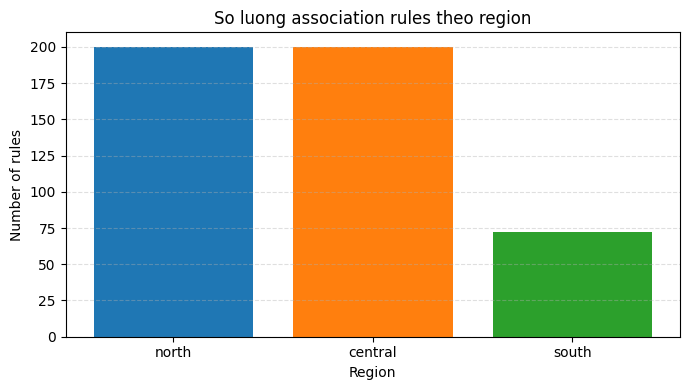

In [9]:
## CELL 15 — FINAL FIX
## Thay toàn bộ Cell 15 bằng cell này
## Thay đổi chính: min_confidence riêng cho từng region

import os
from pyspark import StorageLevel
from pyspark.sql.functions import array_contains, col

all_rules  = {}
all_models = {}

TARGET_RAIN    = ["rain_yes"]
TARGET_EXTREME = ["heatwave", "heavy_rain", "storm"]
TARGETS        = TARGET_RAIN + TARGET_EXTREME

MAX_RULES    = 200
TOP_ITEMSETS = 10

n_parts = max(spark.sparkContext.defaultParallelism * 2, 32)
spark.conf.set("spark.sql.shuffle.partitions", str(n_parts))

RULES_DIR = "rules_output"
os.makedirs(RULES_DIR, exist_ok=True)

# ----------------------------------------------------------
# Tham số riêng theo region
#
# South: heatwave chỉ 0.35% → confidence max ~0.116
#        → hạ min_support + min_confidence để lấy được rules
#        Lift vẫn rất cao (~26) nên rules có giá trị thống kê
#
# North / Central: giữ ngưỡng cũ
# ----------------------------------------------------------
REGION_PARAMS = {
    "north"  : {"min_support": 0.005,  "min_confidence": 0.1},
    "central": {"min_support": 0.005,  "min_confidence": 0.1},
    "south"  : {"min_support": 0.005, "min_confidence": 0.1},
}

# Filter consequent là target
target_filter = None
for t in TARGETS:
    cond = array_contains(col("consequent"), t)
    target_filter = cond if target_filter is None else target_filter | cond

# ----------------------------------------------------------
# Loop
# ----------------------------------------------------------
for region in ["north", "central", "south"]:
    params = REGION_PARAMS[region]
    print(f"\n{'='*55}")
    print(f"  Region : {region.upper()}")
    print(f"  min_support={params['min_support']}  min_confidence={params['min_confidence']}")
    print(f"{'='*55}")

    df_region = (
        dfs_by_region[region]
        .select("items_full")
        .filter(col("items_full").isNotNull())
        .repartition(n_parts)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    tx_count = df_region.count()
    if tx_count == 0:
        print("  >> Không có transaction.")
        df_region.unpersist()
        continue
    print(f"  Transactions: {tx_count:,} | Partitions: {n_parts}")

    fp = FPGrowth(
        itemsCol="items_full",
        minSupport=params["min_support"],
        minConfidence=params["min_confidence"],
        numPartitions=n_parts
    )

    try:
        fp_model = fp.fit(df_region)
    except Exception as e:
        print(f"  ⚠ FPGrowth thất bại: {e}")
        df_region.unpersist()
        continue

    print(f"  >> Tổng frequent itemsets: {fp_model.freqItemsets.count()}")
    print(f"  >> Top {TOP_ITEMSETS} itemsets:")
    fp_model.freqItemsets.orderBy(col("freq").desc()).limit(TOP_ITEMSETS).show(truncate=False)

    target_rules_df = (
        fp_model.associationRules
        .filter(target_filter)
        .orderBy(col("lift").desc())
        .limit(MAX_RULES)
    )

    n_rules = target_rules_df.count()
    print(f"  >> {n_rules} rules về rain/extreme")
    target_rules_df.select("antecedent", "consequent", "support", "confidence", "lift") \
        .show(15, truncate=False)

    target_rules_pd = target_rules_df.toPandas()
    out_path = os.path.join(RULES_DIR, f"rules_{region}.csv")
    target_rules_pd.to_csv(out_path, index=False)
    print(f"  >> Lưu: {out_path}")

    all_rules[region]  = target_rules_pd
    all_models[region] = fp_model

    df_region.unpersist()
    print(f"  >> Giải phóng memory cho {region}.")

print("\n✓ FPGrowth hoàn thành.")
print("Số rules mỗi region:", {r: len(v) for r, v in all_rules.items()})

# Chart 6: so rules moi region
rules_count = {r: len(v) for r, v in all_rules.items()}
if rules_count:
    plt.figure(figsize=(7, 4))
    plt.bar(rules_count.keys(), rules_count.values(), color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    plt.title("So luong association rules theo region")
    plt.xlabel("Region")
    plt.ylabel("Number of rules")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

## 7. Visualisation — Support / Confidence / Lift by region

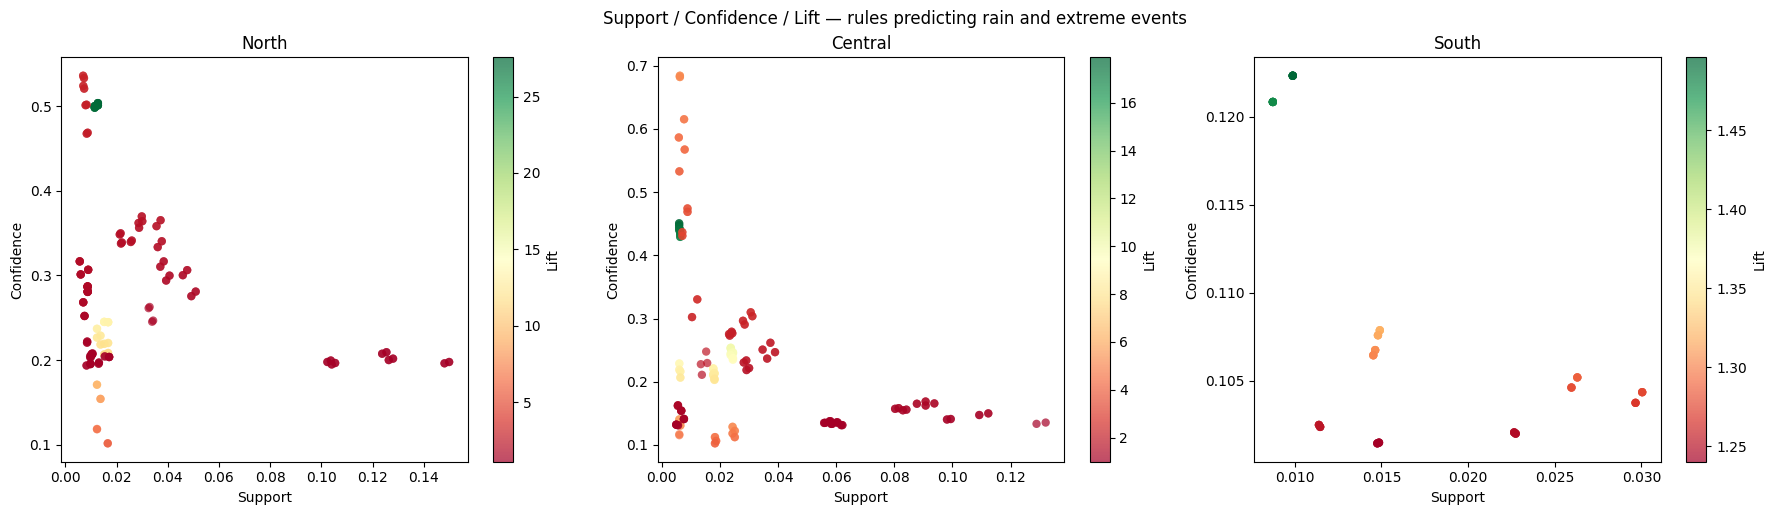

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, region in zip(axes, ["north", "central", "south"]):
    pdf_r = all_rules.get(region)
    if pdf_r is None or pdf_r.empty:
        ax.text(0.5, 0.5, "Aucune règle\ntrouvée", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(region.capitalize())
        continue
    sc = ax.scatter(pdf_r["support"], pdf_r["confidence"],
                    c=pdf_r["lift"], cmap="RdYlGn", alpha=0.7, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Lift")
    ax.set_title(f"{region.capitalize()}")
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence")

plt.tight_layout()
plt.suptitle("Support / Confidence / Lift — rules predicting rain and extreme events", y=1.02)
plt.show()


## 8. Top 10 règles par Lift — comparaison inter-régions

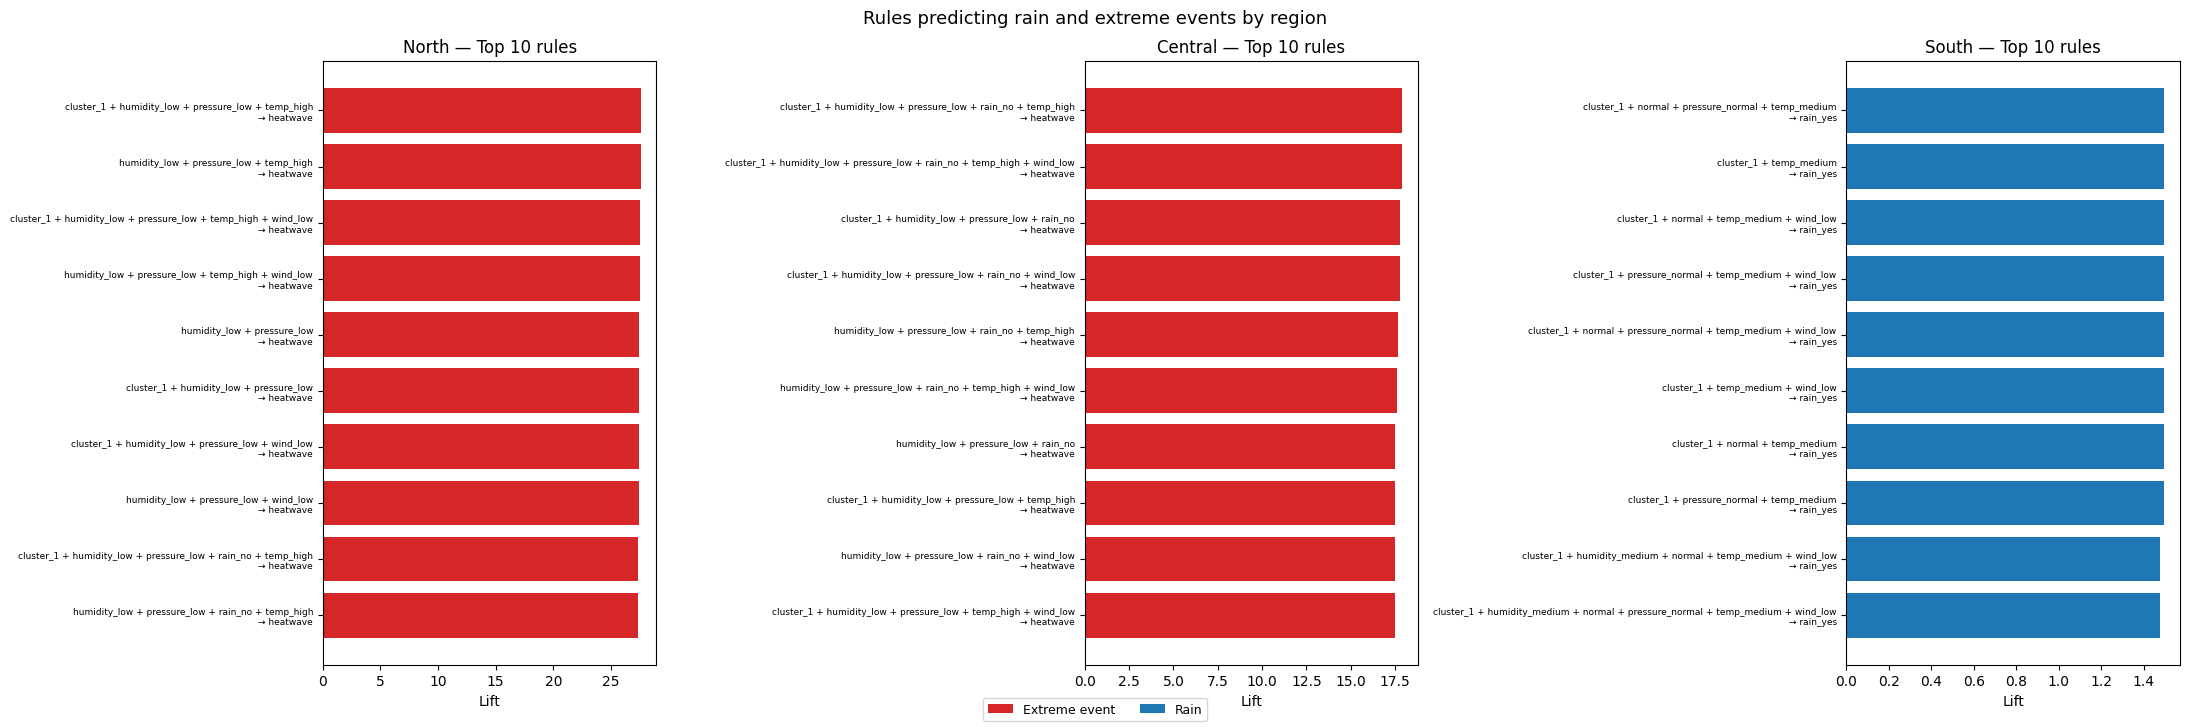

In [11]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, region in zip(axes, ["north", "central", "south"]):
    top = all_rules.get(region)
    if top is None or top.empty:
        ax.text(0.5, 0.5, "Aucune règle", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(region.capitalize())
        continue

    top = top.head(10)  # déjà trié par lift desc, déjà Pandas

    labels = [
        f"{' + '.join(sorted(a))}\n→ {' + '.join(sorted(c))}"
        for a, c in zip(top["antecedent"], top["consequent"])
    ]
    colors = ["#d62728" if any(t in str(c) for t in TARGET_EXTREME) else "#1f77b4"
              for c in top["consequent"]]

    ax.barh(range(len(top)), top["lift"], color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=6.5)
    ax.set_xlabel("Lift")
    ax.set_title(f"{region.capitalize()} — Top 10 rules")
    ax.invert_yaxis()

legend_elements = [
    Patch(facecolor="#d62728", label="Extreme event"),
    Patch(facecolor="#1f77b4", label="Rain")
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=9)
plt.tight_layout()
plt.suptitle("Rules predicting rain and extreme events by region", y=1.02, fontsize=13)
plt.show()


## 9. Heatmap: Most frequent antecedents by region and target


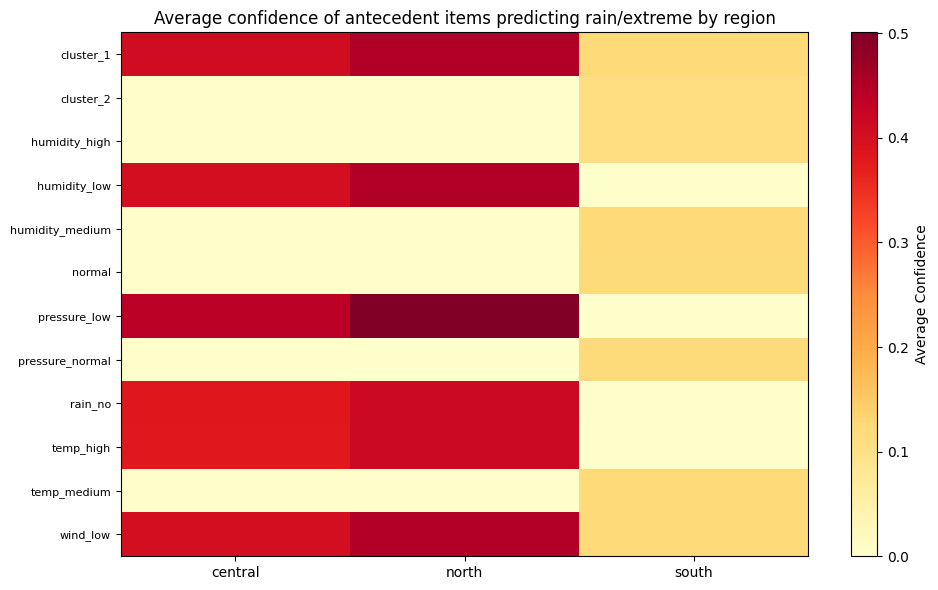

In [12]:
import pandas as pd

records = []
for region in ["north", "central", "south"]:
    top = all_rules.get(region)
    if top is None or top.empty:
        continue
    for _, row in top.head(20).iterrows():
        for item in row["antecedent"]:
            for cons in row["consequent"]:
                records.append({
                    "region": region,
                    "antecedent_item": item,
                    "consequent": cons,
                    "lift": row["lift"],
                    "confidence": row["confidence"]
                })

df_vis = pd.DataFrame(records)

if not df_vis.empty:
    pivot = df_vis.groupby(["region", "antecedent_item"])["confidence"].mean().unstack(0).fillna(0)
    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.4)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    plt.colorbar(im, ax=ax, label="Average Confidence")
    ax.set_title("Average confidence of antecedent items predicting rain/extreme by region")
    plt.tight_layout()
    plt.show()
else:
    print("No rules available for heatmap.")


## 10. Network Graph — Association Rules (antecedent → consequent)


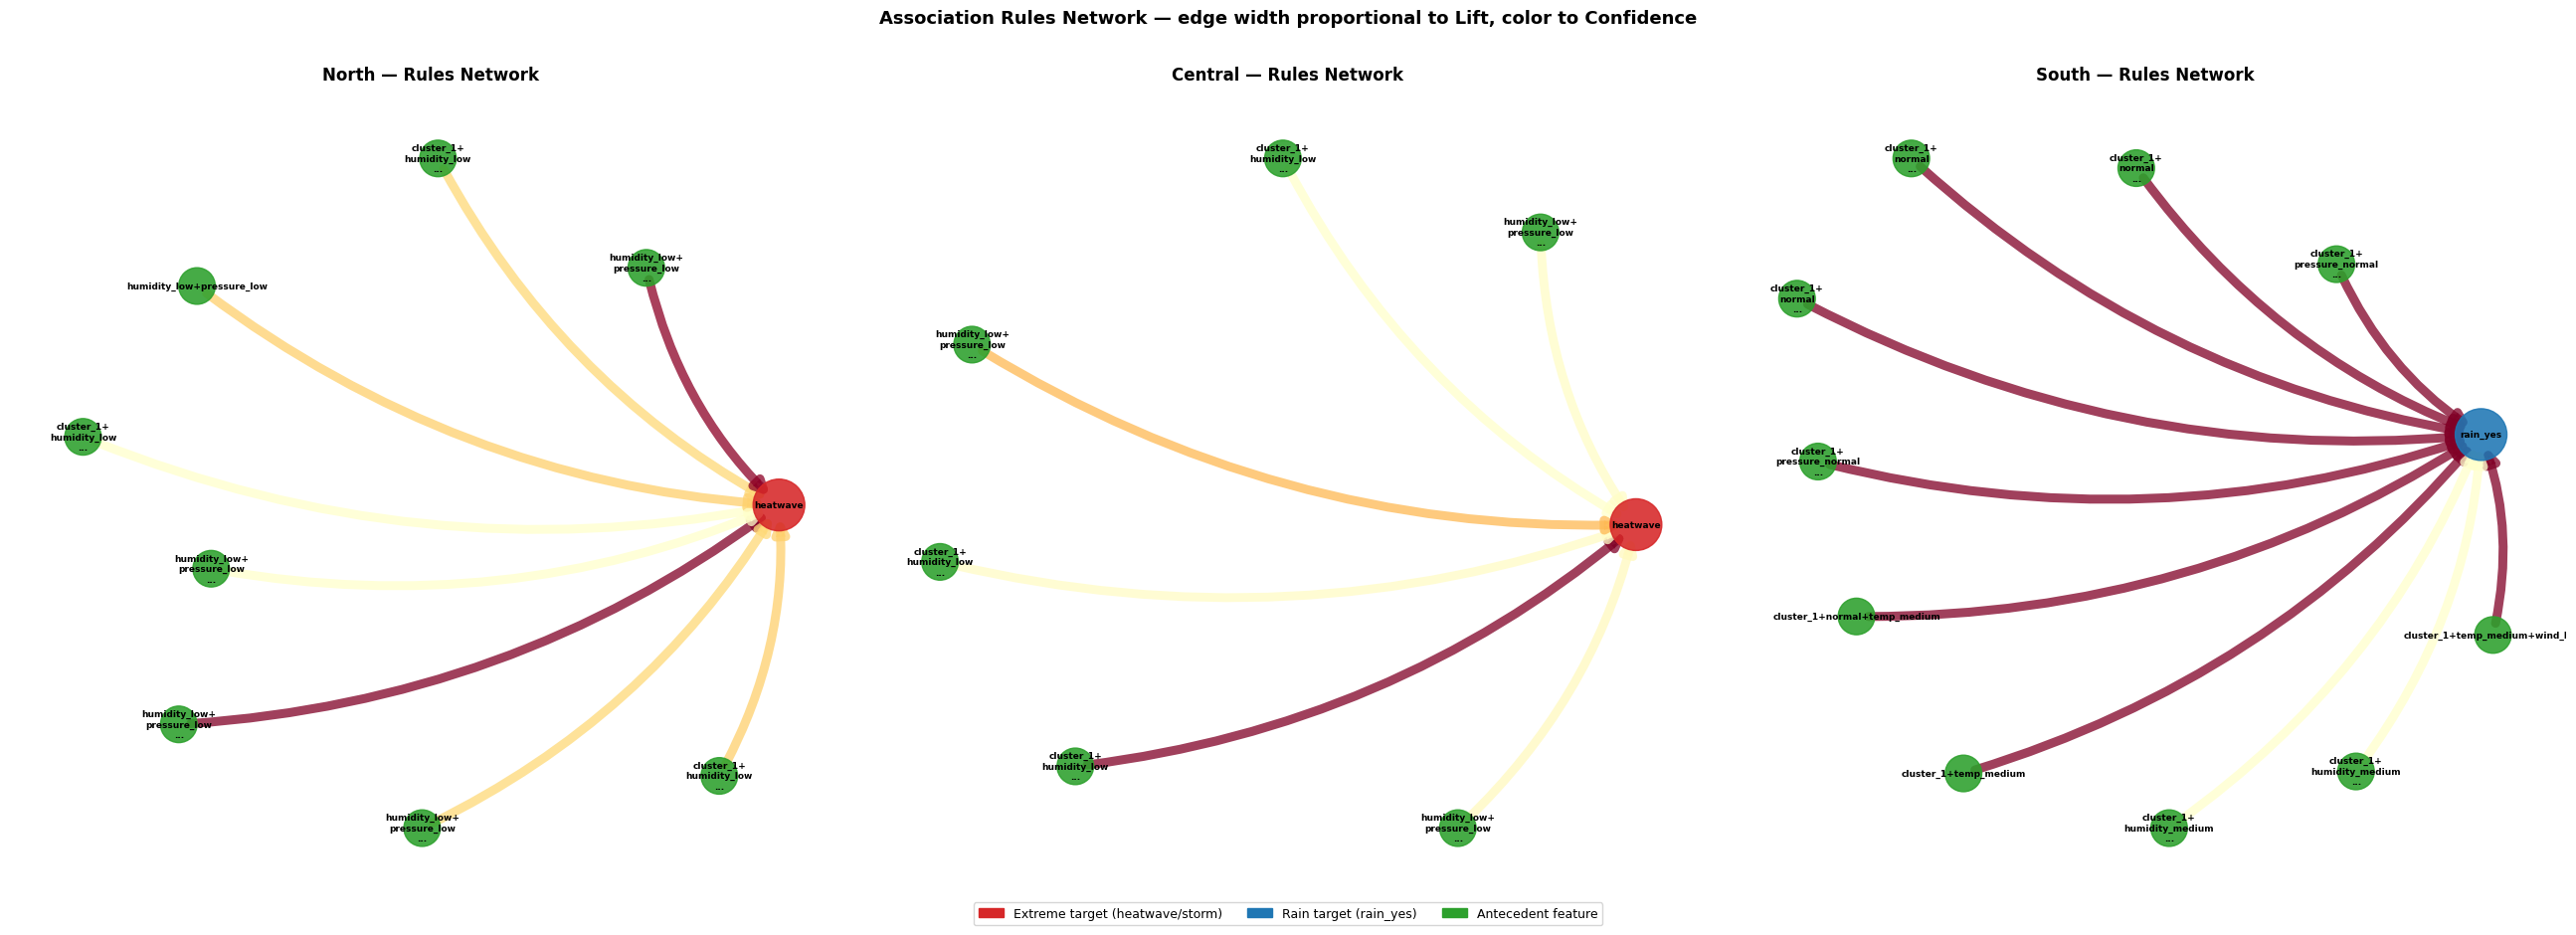

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_rules_network(all_rules, targets, top_n=15, min_lift=1.5):
    """
    Ve network graph noi antecedent items voi consequent (targets).
    - Node do/cam : consequent targets (rain_yes, heatwave, ...)
    - Node xanh la: antecedent items (dieu kien thoi tiet)
    - Edge width  : ty le voi lift
    - Edge color  : ty le voi confidence
    """
    fig, axes = plt.subplots(1, 3, figsize=(26, 9))
    region_list = ["north", "central", "south"]

    TARGET_COLOR  = "#d62728"   # do cho extreme
    RAIN_COLOR    = "#1f77b4"   # xanh duong cho rain
    FEATURE_COLOR = "#2ca02c"   # xanh la cho features

    for ax, region in zip(axes, region_list):
        rules = all_rules.get(region)
        ax.set_title(f"{region.capitalize()} — Rules Network", fontsize=12, fontweight="bold")
        ax.axis("off")

        if rules is None or rules.empty:
            ax.text(0.5, 0.5, "No rules found", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11)
            continue

        top = rules[rules["lift"] >= min_lift].head(top_n)
        if top.empty:
            ax.text(0.5, 0.5, f"No rules with lift >= {min_lift}", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        G = nx.DiGraph()

        for _, row in top.iterrows():
            ant_items  = list(row["antecedent"])
            cons_items = list(row["consequent"])
            lift = row["lift"]
            conf = row["confidence"]

            # Rut gon: chi giu 3 items dau de nhan doc
            short_items = sorted(ant_items)[:3]
            ant_label = "+".join(short_items)
            if len(ant_items) > 3:
                ant_label += f"+{len(ant_items)-3}more"

            for cons in cons_items:
                G.add_edge(ant_label, cons, weight=lift, confidence=conf)

        if G.number_of_nodes() == 0:
            ax.text(0.5, 0.5, "No edges", ha="center", va="center", transform=ax.transAxes)
            continue

        try:
            pos = nx.spring_layout(G, k=3.0, seed=42, iterations=120)
        except Exception:
            pos = nx.circular_layout(G)

        # Node appearance
        node_colors, node_sizes = [], []
        for node in G.nodes():
            if node in ["heatwave", "storm", "heavy_rain"]:
                node_colors.append(TARGET_COLOR); node_sizes.append(1400)
            elif node == "rain_yes":
                node_colors.append(RAIN_COLOR); node_sizes.append(1400)
            else:
                node_colors.append(FEATURE_COLOR); node_sizes.append(700)

        # Edge appearance
        edges   = list(G.edges(data=True))
        lifts   = [d["weight"] for _, _, d in edges]
        confs   = [d["confidence"] for _, _, d in edges]
        max_l   = max(lifts) if lifts else 1
        min_c, max_c = min(confs), max(confs)
        widths  = [1.5 + 5.0 * (l / max_l) for l in lifts]
        norm_c  = [(c - min_c) / (max_c - min_c + 1e-9) for c in confs]
        edge_colors = [plt.cm.YlOrRd(v) for v in norm_c]

        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors, node_size=node_sizes, alpha=0.88)
        nx.draw_networkx_edges(G, pos, ax=ax,
                               width=widths, edge_color=edge_colors,
                               arrows=True, arrowsize=18,
                               connectionstyle="arc3,rad=0.15", alpha=0.75)

        # Rut gon label
        labels = {}
        for node in G.nodes():
            if len(node) > 30:
                parts = node.split("+")
                labels[node] = "+\n".join(parts[:2]) + ("\n..." if len(parts) > 2 else "")
            else:
                labels[node] = node
        nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                                font_size=6.5, font_weight="bold")

    legend_handles = [
        mpatches.Patch(color=TARGET_COLOR,  label="Extreme target (heatwave/storm)"),
        mpatches.Patch(color=RAIN_COLOR,    label="Rain target (rain_yes)"),
        mpatches.Patch(color=FEATURE_COLOR, label="Antecedent feature"),
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(
        "Association Rules Network — edge width proportional to Lift, color to Confidence",
        fontsize=13, y=1.01, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

plot_rules_network(all_rules, TARGETS, top_n=10, min_lift=1)
